In [1]:
from utils.datacrea import prepare_footprint, open_glo30_dem, get_dataset_by_crs, make_custom_dataset
from utils.opentopo_api import download_glo30_from_gdf
from utils.copernicus_api import download_sentinel_files
from utils.infer_patch import infer_dataset
from utils.plot_utils import interactive_plot
from models.convnext import load_model
from utils.dataset import get_custom_dataset_path

xFormers not available
xFormers not available


In [ ]:
# Use this noteboob to download and infer out model whereever you like
# To do this, we use opentopography and copernicus to download data, where
# you will need to create an account (it's free)

# Note that it is designed to work at scale smaller than a Sentinel-2 Tile (100x100 km)

""" API Keys """
# your OpenTopography API key
# you can get one by creating an account on https://opentopography.org/
API_key_OpenTopo = 'keykeykey'

# your username and password of your copernicus account https://dataspace.copernicus.eu/
username_copernicus = 'username'
passw_copernicus ='password'

""" path """
# folder to save the downloads/inference
output_folder = 'custom_data'

""" data to download """
# name of your data
name = 'custom_zone_example'

# footprint
zone_crs = 4326 # the CRS of your coords footprint
north=45.648372
south=45.637854
east=5.879629
west=5.862447

# date
start_date = '2025-06-01' # YYYY-MM-DD
end_date = '2025-08-01'

"""modele"""
# multi ou mono model
model_type = 'multi'
pretrain_ConvNeXtDPT= 'weights/convNext_base_DPT_finetune.pth'
pretrain_DPTHeadTemporal = 'weights/convNext_base_DPT_multitemp_SimpleRelativePos.pth'
encoder_type = 'gla2'

""" device """
device = 'cuda'


## Downloading

In [3]:
# Geopandas of the footprint, rounded to be divisible by 5120 meters
gdf_footprint = prepare_footprint( north, south, east, west, zone_crs )

### glo30

In [4]:
out_glo = download_glo30_from_gdf( gdf_footprint, API_key_OpenTopo, output_folder, name )

### sentinel-2

In [5]:
out_sent = download_sentinel_files( gdf_footprint, output_folder, name, username_copernicus, passw_copernicus, start_date, end_date, cloud_max = 50 )

---- Downloading Sentinel on  custom_zone_example  from  2025-06-01  to  2025-08-01
> query link [2025, 6, 1] [2025, 8, 1]
found  24
success :  2 failed :  0


# create the custom dataset

In [6]:
glo30_dems = open_glo30_dem( out_glo )
# dict with Sentinel CRS, geometry, date, path
dataset_by_crs = get_dataset_by_crs( out_sent, gdf_footprint )
# create the dataset (interpolation, crop etc..)
make_custom_dataset( dataset_by_crs, glo30_dems, output_folder )

--->  custom_zone_example.tif 4326 (232, 331)


100%|██████████| 24/24 [00:06<00:00,  3.73it/s]


# inference

In [7]:
model_ConvNeXtDPT, temporal_head = load_model( model_type, encoder_type, pretrain_ConvNeXtDPT, pretrain_DPTHeadTemporal, use_weight_from_DPT=False, freeze_bbone=True, device=device )

In [8]:
dataset = get_custom_dataset_path( output_folder, [name] )

custom_zone_example , n images :  24


In [9]:
refined, full_pred_depth, full_pred_var = infer_dataset( dataset, name, model_ConvNeXtDPT, temporal_head, infer_size = 512, encoder_type=encoder_type, device=device, model_type = model_type)

# plot

Output()

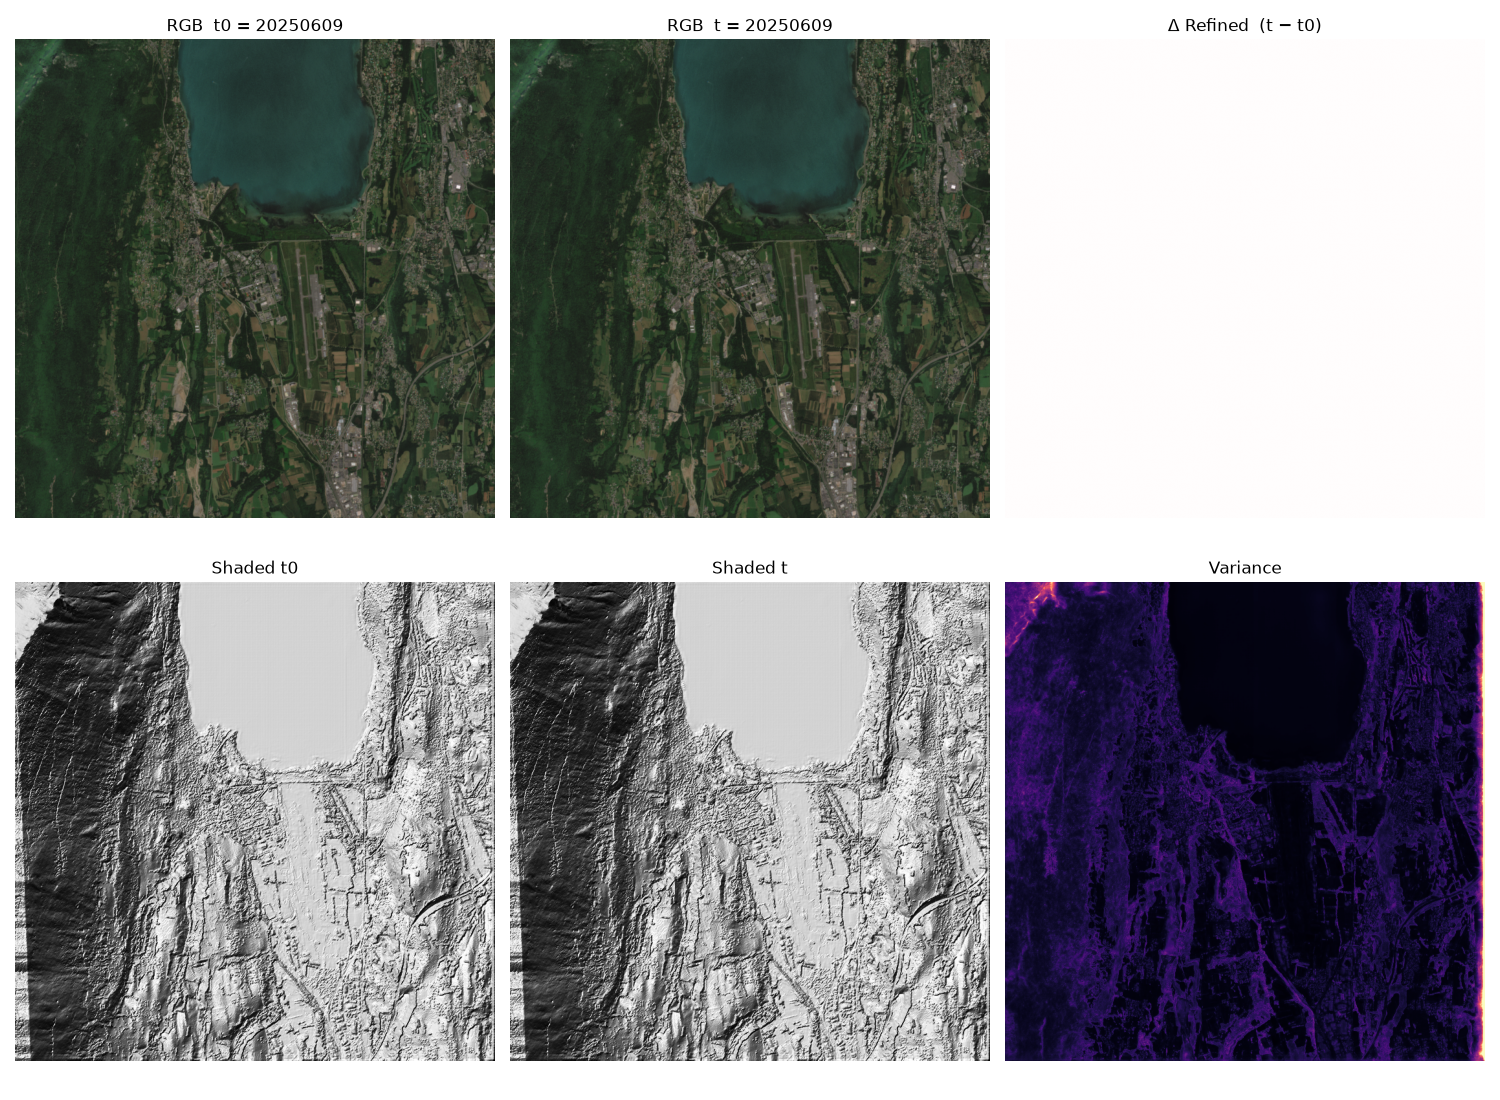

In [10]:
%matplotlib widget

interactive_plot(dataset, refined, full_pred_depth, full_pred_var )